In [ ]:
import kagglehub

# Download latest version
import kagglehub

# Download latest version
path = kagglehub.dataset_download("awsaf49/coco-2017-dataset")

print("Path to dataset files:", path)

100%|██████████| 25.0G/25.0G [03:56<00:00, 114MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/awsaf49/coco-2017-dataset/versions/2


In [1]:
!pip install ultralytics opencv-python-headless matplotlib twilio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.5/983.5 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 70.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from twilio.rest import Client
from google.colab.patches import cv2_imshow


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
model = YOLO('yolov8n.pt')  # Load the nano model


100%|██████████| 6.25M/6.25M [00:00<00:00, 73.6MB/s]


In [4]:
def preprocess_image(image_path):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    cl1 = clahe.apply(img)
    blur = cv2.GaussianBlur(cl1, (3, 3), 0)
    sharp = cv2.addWeighted(cl1, 1.5, blur, -0.5, 0)
    rgb_img = cv2.cvtColor(sharp, cv2.COLOR_GRAY2BGR)
    return rgb_img


In [5]:
def verify_detection(result, image_shape):
    verified = []
    h, w = image_shape[:2]
    for box in result.boxes:
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        area = ((x2 - x1) * (y2 - y1)) / (w * h)
        ar = (x2 - x1) / (y2 - y1 + 1e-5)

        # Verification logic
        if cls in [21, 23, 24, 25]:  # elephant, bear, horse, sheep etc.
            if area > 0.1 and ar > 0.5:
                verified.append((cls, conf, (x1, y1, x2, y2)))
        elif conf > 0.4:
            verified.append((cls, conf, (x1, y1, x2, y2)))
    return verified


In [6]:
def detect_and_alert(image_path):
    img = preprocess_image(image_path)
    results = model.predict(img)[0]
    verified = verify_detection(results, img.shape)

    if verified:
        print("Intrusion Detected!")
        for cls, conf, box in verified:
            print(f"Class: {cls}, Confidence: {conf:.2f}, Box: {box}")
        send_sms_alert()
    else:
        print("No valid detections.")

    cv2_imshow(img)

def send_sms_alert():
    # Replace with your Twilio credentials
    account_sid = 'ACc2c579fdc578f5cef47f3e646f22d531'
    auth_token = 'afafe5c80916217b2b786ce742e9ef1a'
    client = Client(account_sid, auth_token)

    message = client.messages.create(
        body="Alert: Animal intrusion detected in your farmland!",
        from_='+17348083370',
        to='+918106825309'
    )
    print(f"SMS sent: {message.sid}")


Saving img.jpeg to img.jpeg

0: 448x640 1 person, 1 bird, 1 horse, 4 sheeps, 3 cows, 216.3ms
Speed: 10.9ms preprocess, 216.3ms inference, 2.5ms postprocess per image at shape (1, 3, 448, 640)
Intrusion Detected!
Class: 18, Confidence: 0.74, Box: (61, 119, 98, 164)
Class: 18, Confidence: 0.73, Box: (19, 117, 65, 176)
Class: 17, Confidence: 0.70, Box: (0, 60, 64, 156)
Class: 0, Confidence: 0.66, Box: (86, 84, 114, 152)
Class: 19, Confidence: 0.44, Box: (202, 94, 251, 146)
Class: 19, Confidence: 0.40, Box: (191, 84, 250, 146)
SMS sent: SM06566737f9ed063ca63272c9c907285c


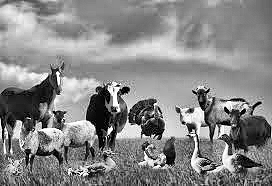

In [8]:
from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
    detect_and_alert(fn)
